In [1]:
import sys, os
sys.path.insert(0, '../src')
os.environ['KMP_WARNINGS'] = '0'

import numpy as np
import matplotlib.pyplot as plt
from PySPIDER.commons.library import Observable
from PySPIDER.discrete.process_library_terms import SRDataset

# Load LJ dataset
positions = np.load('/Users/mirrasangal/Downloads/LJ_data/positions.npy')
vs = np.load('/Users/mirrasangal/Downloads/LJ_data/vs.npy')
deltat = float(np.load('/Users/mirrasangal/Downloads/LJ_data/deltat.npy'))
dims = np.load('/Users/mirrasangal/Downloads/LJ_data/dims.npy')

print('positions shape:', positions.shape)  # (N, 2, T)
print('velocities shape:', vs.shape)
print('deltat:', deltat)
print('domain size:', dims)

N, _, T = positions.shape
print(f'\n{N} particles, 2D, {T} time steps')

positions shape: (9600, 2, 10000)
velocities shape: (9600, 2, 10000)
deltat: 2.539543411945013
domain size: [248.66604111 248.66604111]

9600 particles, 2D, 10000 time steps


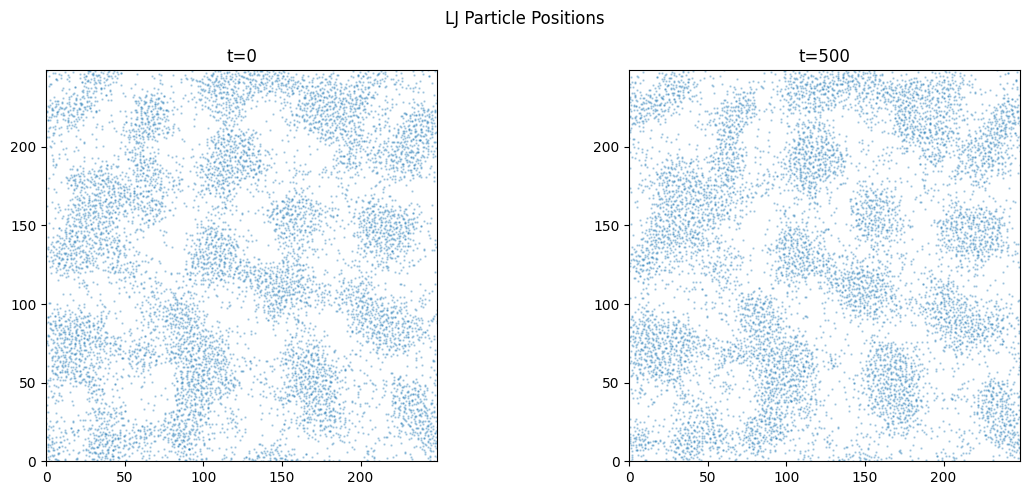

done


In [2]:
# Plot particle positions at t=0 and t=500 to see structure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, t, title in zip(axes, [0, 500], ['t=0', 't=500']):
    ax.scatter(positions[:, 0, t], positions[:, 1, t], s=0.5, alpha=0.3)
    ax.set_xlim(0, dims[0])
    ax.set_ylim(0, dims[1])
    ax.set_title(title)
    ax.set_aspect('equal')

plt.suptitle('LJ Particle Positions')
plt.tight_layout()
plt.savefig('lj_snapshots.png', dpi=100)
plt.show()
print('done')

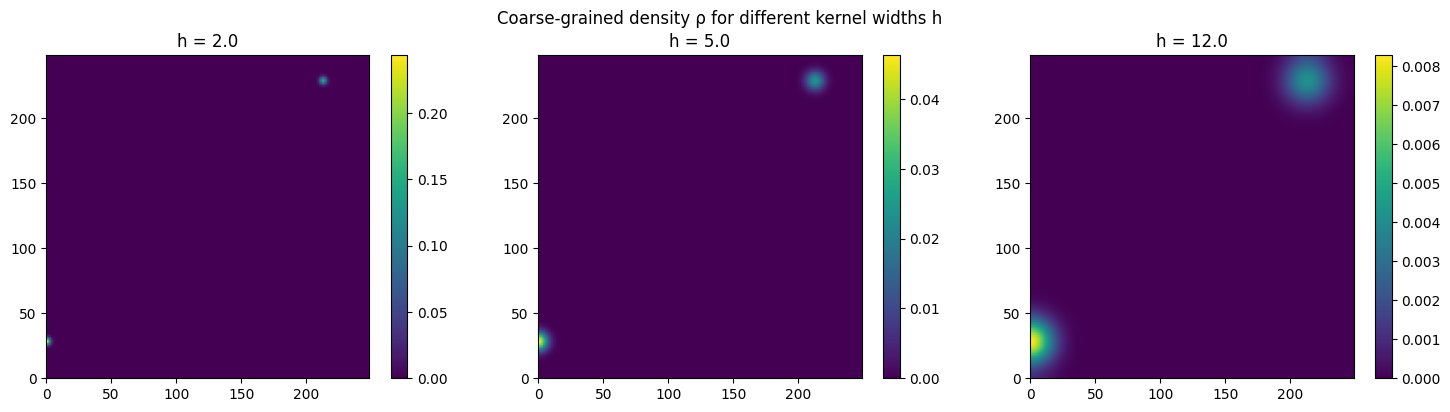

In [3]:
# Subsample time steps to make this faster (use every 100th step)
t_subsample = np.arange(0, T, 100)  # 100 time steps
pos_sub = positions[:, :, t_subsample]  # shape (9600, 2, 100)
vs_sub = vs[:, :, t_subsample]

# Build a coarse-grained density field for one snapshot at a few h values
from scipy.stats import gaussian_kde

def coarse_grain_density(pos_t, grid_size=64, h=5.0, L=248.67):
    """Simple coarse-graining of density at one time step."""
    x = np.linspace(0, L, grid_size)
    y = np.linspace(0, L, grid_size)
    xx, yy = np.meshgrid(x, y)
    xi = np.vstack([xx.ravel(), yy.ravel()])
    
    # Gaussian kernel density estimate
    from scipy.ndimage import gaussian_filter
    density = np.zeros((grid_size, grid_size))
    # bin particles
    ix = np.clip((pos_t[0] / L * grid_size).astype(int), 0, grid_size-1)
    iy = np.clip((pos_t[1] / L * grid_size).astype(int), 0, grid_size-1)
    np.add.at(density, (iy, ix), 1)
    # smooth with gaussian of width h (in grid units)
    h_grid = h / L * grid_size
    density = gaussian_filter(density, sigma=h_grid)
    return density

# Try 3 values of h
h_values = [2.0, 5.0, 12.0]
t_plot = 0  # first time step

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, h in zip(axes, h_values):
    rho = coarse_grain_density(positions[:, :, t_plot], grid_size=128, h=h)
    im = ax.imshow(rho, origin='lower', extent=[0, dims[0], 0, dims[1]], cmap='viridis')
    ax.set_title(f'h = {h}')
    plt.colorbar(im, ax=ax)

plt.suptitle('Coarse-grained density ρ for different kernel widths h')
plt.tight_layout()
plt.savefig('coarse_grain_h_comparison.png', dpi=100)
plt.show()

In [4]:
# Check actual coordinate ranges
print('x range:', positions[:, 0, 0].min(), positions[:, 0, 0].max())
print('y range:', positions[:, 1, 0].min(), positions[:, 1, 0].max())

x range: 0.00751075 248.66378213
y range: 0.01793837 248.63953748


In [6]:
# Debug: check how many particles are being binned
pos_t = positions[:, :, 0]
grid_size = 128
L = 248.67

ix = np.floor(pos_t[:, 0] / L * grid_size).astype(int) % grid_size
iy = np.floor(pos_t[:, 1] / L * grid_size).astype(int) % grid_size

print('ix range:', ix.min(), ix.max())
print('iy range:', iy.min(), iy.max())
print('number of unique ix values:', len(np.unique(ix)))
print('number of unique iy values:', len(np.unique(iy)))
print('pos_t shape:', pos_t.shape)
print('first few positions:', pos_t[:5])

ix range: 0 127
iy range: 0 127
number of unique ix values: 128
number of unique iy values: 128
pos_t shape: (9600, 2)
first few positions: [[2.11996905e+02 3.01412110e-01]
 [2.27328151e+02 2.85317568e+01]
 [1.28149506e+00 6.80602887e+00]
 [1.82841842e+02 2.37909484e+02]
 [8.37308002e+00 2.05119070e-01]]


total particles counted: 9600.0
max density in any cell: 5.0
mean density per cell: 0.5859375
fraction of empty cells: 0.57684326171875


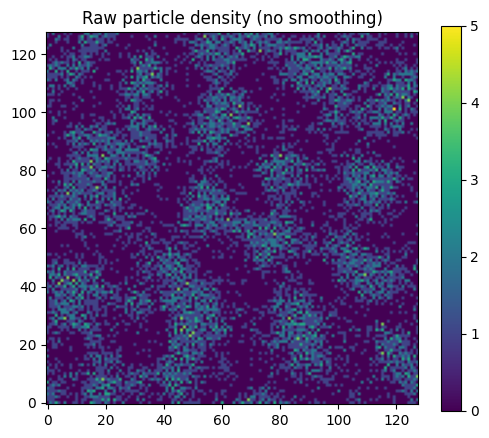

In [7]:
# Check the density map directly
pos_t = positions[:, :, 0]
grid_size = 128
L = 248.67

density = np.zeros((grid_size, grid_size))
ix = np.floor(pos_t[:, 0] / L * grid_size).astype(int) % grid_size
iy = np.floor(pos_t[:, 1] / L * grid_size).astype(int) % grid_size
np.add.at(density, (iy, ix), 1)

print('total particles counted:', density.sum())
print('max density in any cell:', density.max())
print('mean density per cell:', density.mean())
print('fraction of empty cells:', (density == 0).mean())

# Plot the RAW density before smoothing
plt.figure(figsize=(6,5))
plt.imshow(density, origin='lower', cmap='viridis')
plt.colorbar()
plt.title('Raw particle density (no smoothing)')
plt.show()

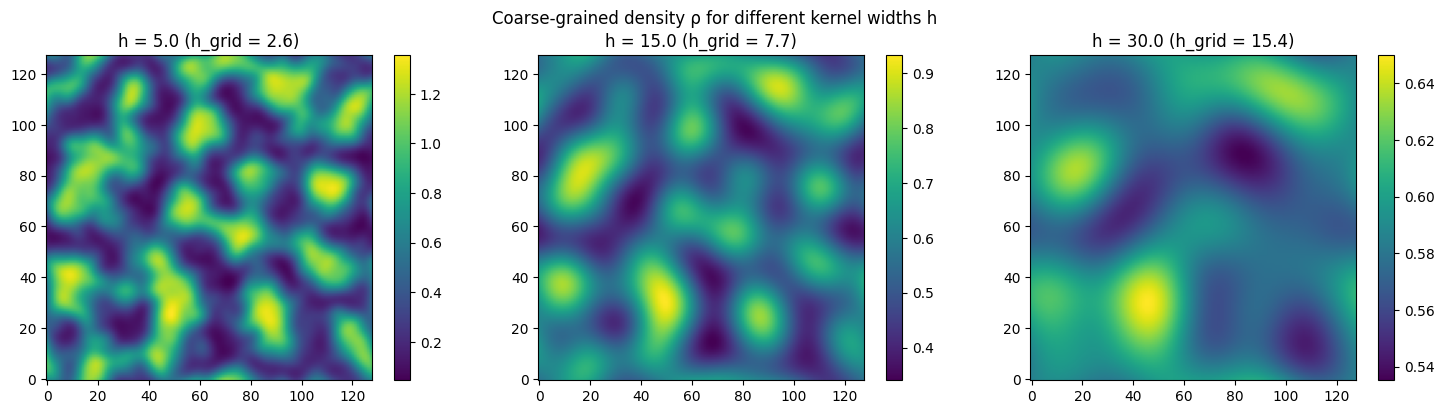

In [8]:
# h values in physical units — need to be larger for this domain
h_values = [5.0, 15.0, 30.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, h in zip(axes, h_values):
    density = np.zeros((grid_size, grid_size))
    np.add.at(density, (iy, ix), 1)
    # h in grid units = h_physical / L * grid_size
    h_grid = h / L * grid_size
    from scipy.ndimage import gaussian_filter
    density = gaussian_filter(density, sigma=h_grid, mode='wrap')
    im = ax.imshow(density, origin='lower', cmap='viridis')
    ax.set_title(f'h = {h} (h_grid = {h_grid:.1f})')
    plt.colorbar(im, ax=ax)

plt.suptitle('Coarse-grained density ρ for different kernel widths h')
plt.tight_layout()
plt.savefig('coarse_grain_h_comparison.png', dpi=100)
plt.show()